## Paper

https://github.com/3dlg-hcvc/tricolo

## Download annotation CSV

In [2]:
!curl -o dataset/text2shape_c13.csv https://aspis.cmpt.sfu.ca/projects/tricolo/data/c13.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
curl: (35) schannel: next InitializeSecurityContext failed: CRYPT_E_NO_REVOCATION_CHECK (0x80092012) - The revocation function was unable to check revocation for the certificate.


## Download ShapeNetCore

Link: https://www.kaggle.com/datasets/hajareddagni/shapenetcorev2

## Read CSV file

In [14]:
import csv
csvPath = "dataset/text2shape_c13.csv"

dataset = []
with open(csvPath, "r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        dataset.append({
            "model_id": row["model_id"],
            "synset_id": row["synset_id"],
            "description": row["description"]
        })

## Check Missing Files

In [15]:
import os

missing = []
valid = []
basePath = os.path.join("dataset", "ShapeNetCore.v2")

for item in dataset:
    mesh_path = os.path.join(basePath, "0" + item["synset_id"], item["model_id"])
    if not os.path.exists(mesh_path):
        missing.append(mesh_path)
        continue
    
    item["mesh_path"] = mesh_path
    valid.append(item)

if missing:
    print(f"Missing {len(missing)} models: {missing[:5]}...")

dataset = valid

print(f"Total models: {len(dataset)}")
print(f"Total missing models: {len(missing)}")
print(f"Missing models ratio: {len(missing) / (len(dataset) + len(missing)) * 100:.2f}%")
print(f"Dataset size: {len(dataset)}")


Missing 312 models: ['dataset\\ShapeNetCore.v2\\04379243\\16d5d43e2e90be359bac1502ed0eb150', 'dataset\\ShapeNetCore.v2\\04379243\\a869ee964836f3abd9daec6dc03c47b8', 'dataset\\ShapeNetCore.v2\\04379243\\5a60822959b28856920de219c00d1c3b', 'dataset\\ShapeNetCore.v2\\04379243\\7cb09d16e07e1d757e1dc03b595bd36c', 'dataset\\ShapeNetCore.v2\\04379243\\2023d474e9252e24720becbd1b051a55']...
Total models: 137963
Total missing models: 312
Missing models ratio: 0.23%
Dataset size: 137963


## Compute CLIP Embeddings

In [3]:
import numpy as np
import tqdm
import torch
from transformers import CLIPProcessor, CLIPModel, CLIPTokenizer, CLIPTextModel

from shapeUtil import shape2Img

modelName = "clip-vit-base-patch32"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tokenizer = CLIPTokenizer.from_pretrained("openai/" + modelName)
textModel = CLIPTextModel.from_pretrained("openai/" + modelName).to(device)

clipModel = CLIPModel.from_pretrained("openai/" + modelName).to(device)
processor = CLIPProcessor.from_pretrained("openai/" + modelName)

outputDir = os.path.join("clip_embeddings", modelName)
os.makedirs(outputDir, exist_ok=True)

for item in tqdm.tqdm(dataset, desc="Processing ShapeNet dataset"):
    modelId = item["model_id"]
    meshPath = os.path.join(item["mesh_path"], "models", "model_normalized.ply")
    textDesc = item["description"]

    tokens = tokenizer(textDesc, return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        textEmbs = textModel(**tokens).last_hidden_state.mean(dim=1).cpu().numpy()

    views = shape2Img(meshPath, 16)
    inputs = processor(images=views, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        img_embeds = clipModel.get_image_features(**inputs)

    img_embeds = img_embeds.cpu().numpy()
    shapeEmb = img_embeds.mean(axis=0)

    np.save(os.path.join(outputDir, f"{modelId}_text.npy"), textEmbs.astype(np.float32))
    np.save(os.path.join(outputDir, f"{modelId}_shape.npy"), shapeEmb.astype(np.float32))

print(f"All embeddings saved in {outputDir}")


c:\Users\Chris PC\AppData\Local\miniconda3\envs\datascience\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


Processing ShapeNet dataset:   0%|          | 0/137963 [00:00<?, ?it/s]c:\Users\Chris PC\AppData\Local\miniconda3\envs\datascience\Lib\site-packages\transformers\models\clip\modeling_clip.py:539: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(
Processing ShapeNet dataset:  99%|█████████▉| 136671/137963 [17:39:51<10:01,  2.15it/s]   


RuntimeError: CUDA error: unknown error
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


## Continue Generating Embeddings

In [6]:
import os
import numpy as np
import tqdm
import torch
from transformers import CLIPProcessor, CLIPModel, CLIPTokenizer, CLIPTextModel

from shapeUtil import shape2Img

modelName = "clip-vit-base-patch32"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

tokenizer = CLIPTokenizer.from_pretrained("openai/" + modelName)
textModel = CLIPTextModel.from_pretrained("openai/" + modelName).to(device)
clipModel = CLIPModel.from_pretrained("openai/" + modelName).to(device)
processor = CLIPProcessor.from_pretrained("openai/" + modelName)

outputDir = os.path.join("clip_embeddings", modelName)
os.makedirs(outputDir, exist_ok=True)

existing_files = sorted([f for f in os.listdir(outputDir) if f.endswith('.npy')])
processed_ids = set()

if existing_files:
    last_text_file = next((f for f in reversed(existing_files) if f.endswith('_text.npy')), None)
    last_shape_file = next((f for f in reversed(existing_files) if f.endswith('_shape.npy')), None)

    if last_text_file and last_shape_file:
        last_text_id = last_text_file.split("_")[0]
        last_shape_id = last_shape_file.split("_")[0]

        if last_text_id == last_shape_id:
            os.remove(os.path.join(outputDir, last_text_file))
            os.remove(os.path.join(outputDir, last_shape_file))

        processed_ids = {f.split("_")[0] for f in existing_files}
        processed_ids.discard(last_text_id)

for item in tqdm.tqdm(dataset, desc="Processing ShapeNet dataset"):
    modelId = item["model_id"]

    if modelId in processed_ids:
        continue

    meshPath = os.path.join(item["mesh_path"], "models", "model_normalized.ply")
    textDesc = item["description"]

    tokens = tokenizer(textDesc, return_tensors="pt", padding=True, truncation=True).to(device)
    with torch.no_grad():
        textEmbs = textModel(**tokens).last_hidden_state.mean(dim=1).cpu().numpy()

    views = shape2Img(meshPath, 16)
    inputs = processor(images=views, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        img_embeds = clipModel.get_image_features(**inputs)

    img_embeds = img_embeds.cpu().numpy()
    shapeEmb = img_embeds.mean(axis=0)

    np.save(os.path.join(outputDir, f"{modelId}_text.npy"), textEmbs.astype(np.float32))
    np.save(os.path.join(outputDir, f"{modelId}_shape.npy"), shapeEmb.astype(np.float32))

print(f"All embeddings saved in {outputDir}")


Using device: cuda


Processing ShapeNet dataset: 100%|██████████| 137963/137963 [00:02<00:00, 59678.79it/s]

All embeddings saved in clip_embeddings\clip-vit-base-patch32


## Check Embeddings

In [8]:
all_ids = set(item["model_id"] for item in dataset)
generated_text_ids = set(f.split("_text.npy")[0] for f in os.listdir(outputDir) if f.endswith("_text.npy"))
generated_shape_ids = set(f.split("_shape.npy")[0] for f in os.listdir(outputDir) if f.endswith("_shape.npy"))

missing_text_ids = all_ids - generated_text_ids
missing_shape_ids = all_ids - generated_shape_ids

if missing_text_ids or missing_shape_ids:
    print(f"Missing embeddings detected:")
    if missing_text_ids:
        print(f"- Missing text embeddings for {len(missing_text_ids)} items: {missing_text_ids}")
    if missing_shape_ids:
        print(f"- Missing shape embeddings for {len(missing_shape_ids)} items: {missing_shape_ids}")
else:
    print("All embeddings are present.")


All embeddings are present and accounted for.


## Load Dataset

In [9]:
from dataset import CLIPEmbeddingDataset

"""
    Dataset: Expected to be in a folder <rootDir>/dataset (complete dataset), <rootDir>/train (train split), <rootDir>/val (validation split), <rootDir>/test (test split)
    CSV File: Needed for Metadata, see section: "Download annotation CSV" for a download link
"""

dataset = CLIPEmbeddingDataset(rootDir="clip_embeddings/clip-vit-base-patch32", csvFile="dataset/text2shape_c13.csv")

print(dataset)
sample = dataset[0]
print("Sample:", sample)
############################################################################################################################################################################

print("\n")

categories = ["02691156", "02808440"]
dataset = dataset.filterByCategories(categories)

print(dataset)
sample = dataset[0]
print("Sample:", sample)

############################################################################################################################################################################

print("\n")

categories = ["02691156", "02808440"]
dataset2 = CLIPEmbeddingDataset(rootDir="clip_embeddings/clip-vit-base-patch32", csvFile="dataset/text2shape_c13.csv", categories=categories)

print(dataset2)
sample = dataset2[0]
print("Sample:", sample)

############################################################################################################################################################################

print("\n")

dataset3 = CLIPEmbeddingDataset("clip_embeddings/clip-vit-base-patch32", "dataset/text2shape_c13.csv")

trainSet, valSet, testSet = dataset3.split(trainRatio=0.8, valRatio=0.1)

print(f"Train Dataset Size: {len(trainSet)}")
print(f"Validation Dataset Size: {len(valSet)}")
print(f"Test Dataset Size: {len(testSet)}")

Category Distribution: {'loudspeaker': 7994, 'table': 41952, 'sofa': 15913, 'lamp': 11614, 'chair': 33134, 'bookshelf': 2216, 'display': 5464, 'clock': 3259, 'trash bin': 1721, 'cabinet': 7885, 'bathtub': 4302, 'file cabinet': 1452, 'bed': 1095}
Missing 274 models from CSV: ['16d5d43e2e90be359bac1502ed0eb150', 'a869ee964836f3abd9daec6dc03c47b8', '2023d474e9252e24720becbd1b051a55', 'c9daf1fc28a95dda166ddaef2c2c61ae', '5ef9520bbefc05c9e8b292c1c2152aed']...
CLIPEmbeddingDataset Summary:
  Root Directory: clip_embeddings/clip-vit-base-patch32\dataset
  CSV File: dataset/text2shape_c13.csv
  Total Samples: 138001
  Unique Categories: 13
Sample: {'category': 'loudspeaker', 'model_id': '5551b67ffe95c01b73c7253ec9acd58b', 'synset_id': '3691459', 'description': 'a white beats speaker unit with a platform for a iphone.', 'textEmbedding': tensor([[ 2.6253e-01, -1.4366e+00, -4.8817e-01, -2.1273e-01,  5.4685e+00,
          3.8925e-01, -5.4856e-02,  1.4210e+00, -1.7422e-01,  5.7353e-01,
          1.

## Analyse Dataset

Category Distribution: {'loudspeaker': 7994, 'table': 41952, 'sofa': 15913, 'lamp': 11614, 'chair': 33134, 'bookshelf': 2216, 'display': 5464, 'clock': 3259, 'trash bin': 1721, 'cabinet': 7885, 'bathtub': 4302, 'file cabinet': 1452, 'bed': 1095}
Missing 274 models from CSV: ['16d5d43e2e90be359bac1502ed0eb150', 'a869ee964836f3abd9daec6dc03c47b8', '2023d474e9252e24720becbd1b051a55', 'c9daf1fc28a95dda166ddaef2c2c61ae', '5ef9520bbefc05c9e8b292c1c2152aed']...


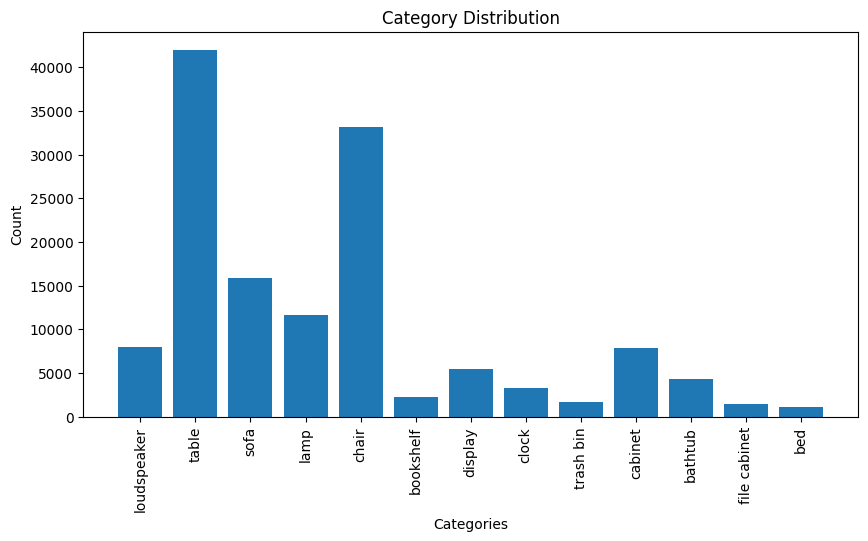

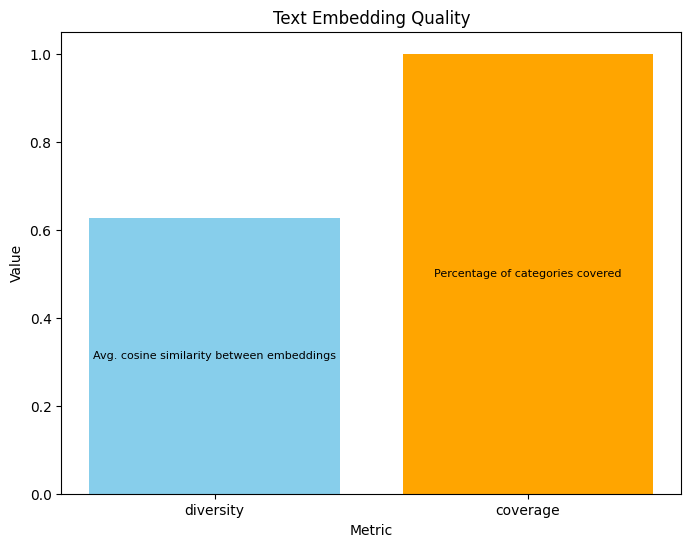

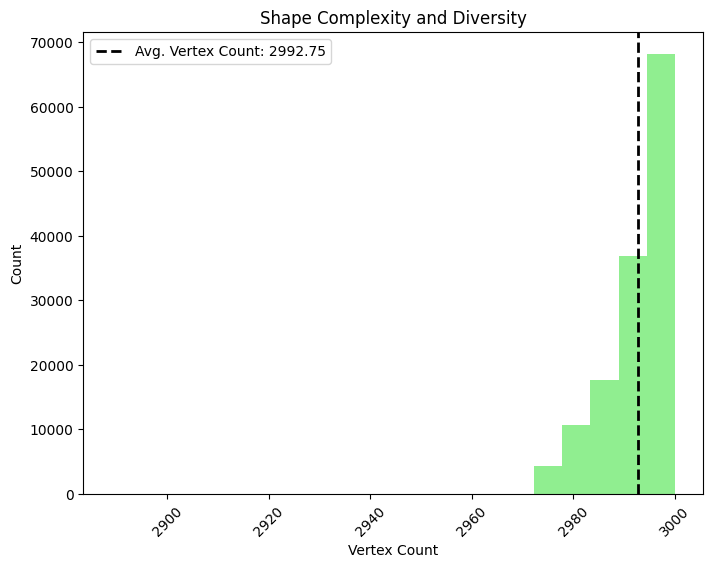

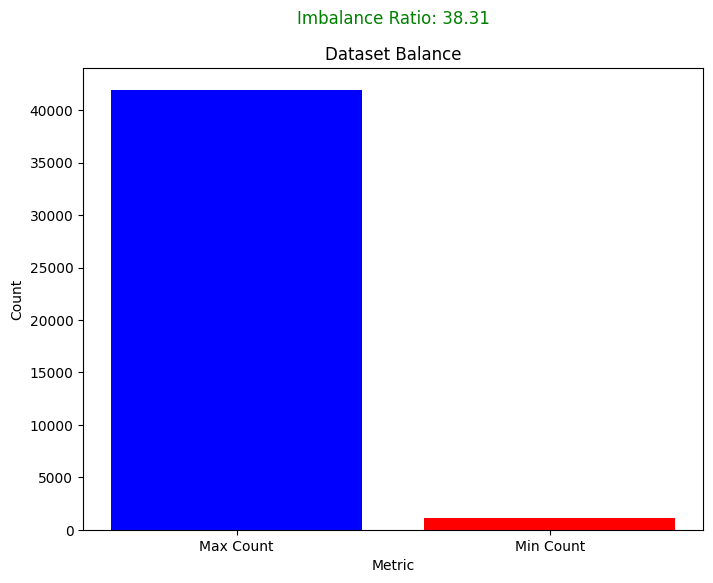

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from dataset import CLIPEmbeddingDataset, categoryDistribution, txtEmbQuality, shapeComplexityAndDiversity, textShapeAlignment, coverageShapenetCategories, dataQuality, balanced

dataset = CLIPEmbeddingDataset(rootDir="clip_embeddings/clip-vit-base-patch32", csvFile="dataset/text2shape_c13.csv")

data = dataset.data

#textQuality = txtEmbQuality(data)
#print("Text Embedding Quality:", textQuality)

#shapeComplexity = shapeComplexityAndDiversity(dataset)
#print("Shape Complexity and Diversity:", shapeComplexity)

#alignmentScore = textShapeAlignment(data)
#print("Text-Shape Alignment Average Cosine Similarity:", alignmentScore)

#qualityScore = dataQuality(data)
#print("Data Quality (Corruption Percentage):", qualityScore, "%")

#balanceInfo = balanced(data)
#print("Dataset Balance:", balanceInfo)

textQuality = {'diversity': 0.62714666, 'coverage': 1.0}

balanceInfo = {'max_count': 41952, 'min_count': 1095, 'imbalance_ratio': 38.31232876712329}

shapeComplexity = {
    'avgVertCnt': 2992.753310670252,
    'VertCntDist': (
        np.array([   10,     5,     0,     0,     5,     0,     5,     0,     0,
                     5,    15,    10,    50,    55,    47,  4298, 10736, 17628,
                     36926, 68168]),
        np.array([2889.  , 2894.55, 2900.1 , 2905.65, 2911.2 , 2916.75, 2922.3 ,
                  2927.85, 2933.4 , 2938.95, 2944.5 , 2950.05, 2955.6 , 2961.15,
                  2966.7 , 2972.25, 2977.8 , 2983.35, 2988.9 , 2994.45, 3000.  ])
    )
}

categoryCnts = categoryDistribution(data)
plt.figure(figsize=(10, 5))
plt.bar(categoryCnts.keys(), categoryCnts.values())
plt.xticks(rotation=90)
plt.title("Category Distribution")
plt.ylabel("Count")
plt.xlabel("Categories")
plt.savefig('dataset_hist.svg', format='svg', dpi=1200)
plt.show()

# 1. Visualize Text Embedding Quality (Diversity and Coverage)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
txtEmbLabels = list(textQuality.keys())
txtEmbVals = list(textQuality.values())
bars = ax.bar(txtEmbLabels, txtEmbVals, color=['skyblue', 'orange'])
ax.set_title('Text Embedding Quality')
ax.set_ylabel('Value')
ax.set_xlabel('Metric')
ax.text(bars[0].get_x() + bars[0].get_width()/2, bars[0].get_height()/2, 
        "Avg. cosine similarity between embeddings", ha='center', va='center', fontsize=8, color='black')
ax.text(bars[1].get_x() + bars[1].get_width()/2, bars[1].get_height()/2, 
        "Percentage of categories covered", ha='center', va='center', fontsize=8, color='black')
plt.savefig('text_embedding_quality.svg', format='svg', dpi=1200) 
plt.show()

# 2. Visualize Shape Complexity and Diversity (Vertex Count Distribution)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
counts, binEdges = shapeComplexity['VertCntDist']
ax.bar(binEdges[:-1], counts, width=np.diff(binEdges), align='edge', color='lightgreen')
ax.axvline(shapeComplexity['avgVertCnt'], color='black', linestyle='--', linewidth=2, label=f'Avg. Vertex Count: {shapeComplexity["avgVertCnt"]:.2f}')
ax.set_title('Shape Complexity and Diversity')
ax.set_ylabel('Count')
ax.set_xlabel('Vertex Count')
ax.legend()
plt.xticks(rotation=45)
plt.savefig('vertex_dist.svg', format='svg', dpi=1200)
plt.show()

# 3. Visualize Dataset Balance (Max, Min Counts and Imbalance Ratio)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
balanceLabels = ['Max Count', 'Min Count']
balanceValues = [balanceInfo['max_count'], balanceInfo['min_count']]
ax.bar(balanceLabels, balanceValues, color=['blue', 'red'])
ax.set_title('Dataset Balance')
ax.set_ylabel('Count')
ax.set_xlabel('Metric')
imbalanceTxt = f"Imbalance Ratio: {balanceInfo['imbalance_ratio']:.2f}"
max_value = max(balanceValues)
ax.text(0.5, max_value + (max_value * 0.15), imbalanceTxt, ha='center', fontsize=12, color='green')
plt.savefig('dataset_balance.svg', format='svg', dpi=1200)
plt.show()


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Local checkpoint path is invalid or does not exist. Proceeding with the pre-trained model.
['a 3d model of a plane on a gray background', 'a 3d model of a small boat on a black background', 'a white boat on top of a gray background', 'a 3d model of a giraffe on a gray background', 'a 3d model of a white airplane on a black background', 'a 3d printed model of a boat on a black background', 'a white angel sitting on top of a ledge', 'a 3d model of a boat on top of a gray surface', 'an angel on the ground', 'the angel in the middle of the ocean', 'and many more.\n\nThis is an open-access article distributed under the terms of The Creative Commons Attribution License, which permits unrestricted use, distribution, and reproduction in']


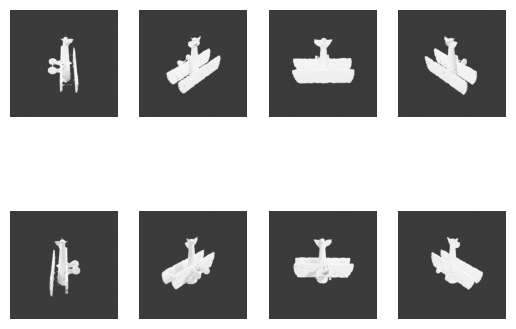

In [6]:
import matplotlib.pyplot as plt
import bpy
from mathutils import Vector
from PIL import Image
import numpy as np

from caption import ModelCaptionGenerator

model_path = r"C:\Users\Chris PC\Desktop\Development\Uni\Machine Learning for 3D Geometries\project\dataset\ShapeNetCore.v2\02691156\1a04e3eab45ca15dd86060f189eb133\models\model_normalized.ply"

check_pnt = "blip2_pretrained_flant5xxl.pth"

def setup_blender_scene():
    # Remove existing objects
    bpy.ops.object.select_all(action='DESELECT')
    bpy.ops.object.select_by_type(type='MESH')
    bpy.ops.object.delete()
    
    # Camera setup
    bpy.context.scene.camera.location = Vector((0, -3, 1.5))
    bpy.context.scene.camera.data.clip_start = 0.1
    bpy.context.scene.camera.data.clip_end = 1000
    
    # Rendering setup
    bpy.context.scene.render.resolution_x = 512
    bpy.context.scene.render.resolution_y = 512
    bpy.context.scene.render.engine = 'CYCLES'
    bpy.context.scene.cycles.samples = 64

    # Lighting setup (Three-point lighting)
    add_light("KeyLight", energy=1000, location=(4, -4, 4))
    add_light("FillLight", energy=300, location=(-4, -4, 2))
    add_light("RimLight", energy=600, location=(0, 4, 4))

def add_light(name, energy, location):
    bpy.ops.object.light_add(type='AREA', location=location)
    light = bpy.context.object
    light.name = name
    light.data.energy = energy

def normalize_and_center_object():
    # Center and scale the object to fit within the view
    objects = [obj for obj in bpy.context.scene.objects if obj.type == 'MESH']
    bbox_min = Vector((float('inf'), float('inf'), float('inf')))
    bbox_max = Vector((float('-inf'), float('-inf'), float('-inf')))
    
    for obj in objects:
        for vertex in obj.bound_box:
            coord = obj.matrix_world @ Vector(vertex)
            bbox_min = Vector(map(min, bbox_min, coord))
            bbox_max = Vector(map(max, bbox_max, coord))
    
    center = (bbox_min + bbox_max) / 2
    dimensions = bbox_max - bbox_min
    max_dim = max(dimensions)
    
    for obj in objects:
        obj.location -= center
        obj.scale /= max_dim

    bpy.context.view_layer.update()

def generate_views(model_path):
    # Import 3D model
    setup_blender_scene()
    bpy.ops.wm.ply_import(filepath=model_path)

    normalize_and_center_object()
    views = []

    # Render 8 views
    camera = bpy.context.scene.camera
    for i in range(8):
        angle = i * 45  # 360°/8 = 45°
        camera.location.x = 2.0 * np.cos(np.radians(angle))
        camera.location.y = 2.0 * np.sin(np.radians(angle))
        camera.location.z = 1.5

        direction = Vector((0, 0, 0)) - camera.location
        rot_quat = direction.to_track_quat('-Z', 'Y')
        camera.rotation_euler = rot_quat.to_euler()

        # Render image
        temp_path = f"/tmp/render_view_{i}.png"
        bpy.context.scene.render.filepath = temp_path
        bpy.ops.render.render(write_still=True)
        
        # Load the rendered image
        views.append(Image.open(temp_path).convert("RGB"))

    return views

# Generate views for the model
views = generate_views(model_path)

for i, view in enumerate(views):
    plt.subplot(2, 4, i+1)
    plt.imshow(view)
    plt.axis('off')


generator = ModelCaptionGenerator(model_type='pretrain_flant5xxl', use_qa=False)
viuews = generator.generate_views(model_path)

captions = generator.process_model(model_path)

print(captions)


## Check different shapes

c:\Users\Chris PC\AppData\Local\miniconda3\envs\blender\Lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\Chris PC\AppData\Local\miniconda3\envs\blender\Lib\site-packages\lavis\models\eva_vit.py:433: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless the

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

c:\Users\Chris PC\AppData\Local\miniconda3\envs\blender\Lib\site-packages\lavis\models\blip2_models\blip2.py:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = t

['a white giraffe on a black background', 'an image of a white knife on a black background', 'a white plane on a black background', 'a white arrow on a black background', 'the letter i in white on a black background', 'a 3d model of a plane on a grey background', 'a white airplane is shown on a black background', 'a white airplane is shown on a black background\n\nThis is an example of how to create an object that can be used as a model for a computer program. The object is created using the following code:\n ( defun my-model () " Create a new model. " ( let']
['a white knife on a black background', 'a white airplane flying in the air on a black background', 'a white airplane on a gray background', 'a white airplane flying in the air on a black background', 'a white knife on a black background', 'a white airplane flying in the air on a black background', 'a white airplane on a gray background', 'a white airplane icon on a black background\n\nA black-and-white photo of a man who was sho

KeyboardInterrupt: 

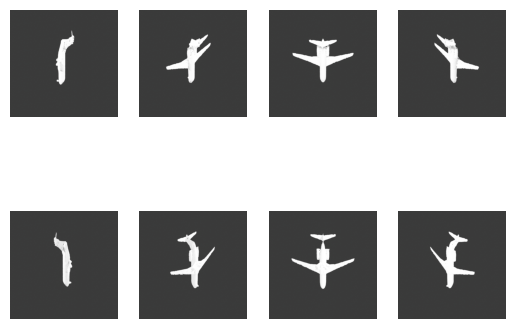

In [8]:
import os

categoryPath = r"C:\Users\Chris PC\Desktop\Development\Uni\Machine Learning for 3D Geometries\project\dataset\ShapeNetCore.v2\02691156"
numModels = 10

generator = ModelCaptionGenerator(model_type='pretrain_flant5xxl', use_qa=False, local_checkpoint_path=check_pnt)

for root, dirs, files in os.walk(categoryPath):
    for file in files:
        if file.endswith(".ply"):
            model_path = os.path.join(root, file)
            captions = generator.process_model(model_path)
            print(captions)

            # Generate views for the model
            views = generate_views(model_path)

            for i, view in enumerate(views):
                plt.subplot(2, 4, i+1)
                plt.imshow(view)
                plt.axis('off')

            numModels -= 1
            if numModels == 0:
                break